In [56]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Part 1 : Stock prices and news

1. View price trends

/var/folders/vj/1dzb5n4d64vd6jbcprcbjkjc0000gn/T/ipykernel_78502/1672139258.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  prices["Date"] = pd.to_datetime(prices["Date"])


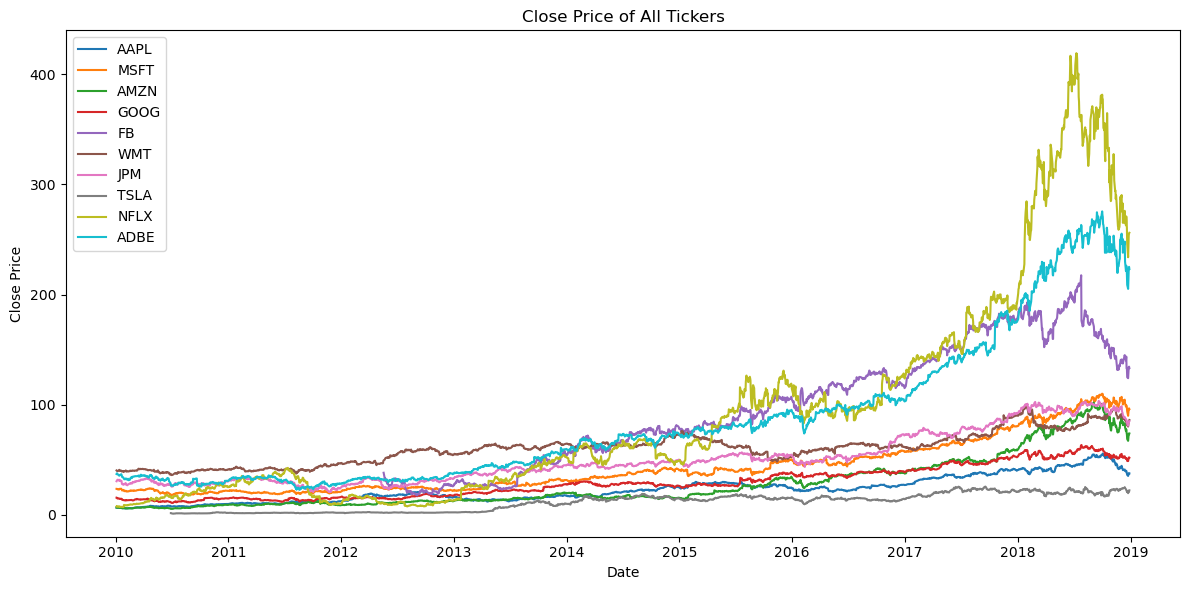

In [57]:
DATA_DIR = Path("../data/")

prices = pd.read_csv(DATA_DIR / 'prices_data.csv')
prices["Date"] = pd.to_datetime(prices["Date"])

tickers = prices["ticker"].unique()
plt.figure(figsize=(12, 6))

for t in tickers:
    sub = prices[prices["ticker"] == t].sort_values("Date")
    plt.plot(sub["Date"], sub["Close"], label=t)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Close Price of All Tickers")
plt.tight_layout()
plt.show()

2. Prepare news data

In [58]:
headlines = pd.read_csv(DATA_DIR / "headlines.csv")

# clean headlines
headlines = headlines.dropna(subset=["ticker", "headline"])
headlines = headlines[headlines["ticker"].str.strip() != ""]
headlines = headlines[headlines["headline"].str.strip() != ""]
headlines["ticker"] = headlines["ticker"].str.strip().str.upper()
headlines["date"] = pd.to_datetime(headlines["date"]).dt.date

headlines.head()

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02
2,AEIS,Advanced Energy Industries (NASDAQ:AEIS):,2011-05-02
3,LOCM,Local.com (NASDAQ:LOCM):,2011-05-02
4,CYDEQ,CyberDefender (CYDE):,2011-05-02


3. Calculate CAR

In [59]:
prices["Date"] = pd.to_datetime(prices["Date"],  utc=True)
prices["date"] = prices["Date"].dt.date

# sort by date, calculate daily return
prices = prices.sort_values(["ticker", "Date"])
prices["ret"] = prices.groupby("ticker")["Close"].pct_change()

g = prices.groupby("ticker")["ret"]
prices["ret_m1"] = g.shift(1)    # t-1
prices["ret_p1"] = g.shift(-1)   # t+1
prices["ret_p2"] = g.shift(-2)   # t+2
prices["ret_p3"] = g.shift(-3)   # t+3

prices["CAR_m1_p3"] = (
    prices["ret_m1"]
    + prices["ret"]
    + prices["ret_p1"]
    + prices["ret_p2"]
    + prices["ret_p3"]
)

price_cols = ["ticker", "date", "Close", "CAR_m1_p3"]
prices_small = prices[price_cols].copy()

prices_small.head()

,ticker,date,Close,CAR_m1_p3
0,AAPL,2010-01-04,6.505279,NaN
1,AAPL,2010-01-05,6.516527,NaN
2,AAPL,2010-01-06,6.412873,-0.018199
3,AAPL,2010-01-07,6.401018,-0.031303
4,AAPL,2010-01-08,6.443573,-0.001292


4. Merge prices and news

In [60]:
df_all = pd.merge(
    headlines, prices_small, 
    on=["ticker", "date"],
    how="left"
)

df_all = df_all.dropna(subset=["CAR_m1_p3"]).reset_index(drop=True)
df_all = df_all.rename(columns={"CAR_m1_p3": "eventRet"})

df_all.head(), df_all.shape
df_all.to_csv(DATA_DIR / "combined_car_m1_p3.csv", index=False)

## Part 2: Sentiment Information

In [61]:
# %pip install textblob

1. Sentiment scores

In [62]:
from textblob import TextBlob

data_df = df_all.copy()
data_df["headline"] = data_df["headline"].astype(str)

# for each headline, calculate sentiment [-1, 1]
data_df["sent_blob"] = data_df["headline"].apply(
    lambda txt: TextBlob(txt).sentiment.polarity
)

data_df[["ticker", "date", "headline", "eventRet", "sent_blob"]].head()

,ticker,date,headline,eventRet,sent_blob
0,AMZN,2011-05-02,Whole Foods (WFMI) -5.2% following a downgrade...,0.011007,0.262500
1,NFLX,2011-05-02,Netflix (NFLX +1.1%) shares post early gains a...,-0.016891,-0.043750
2,MSFT,2011-05-10,The likely winners in Microsoft's (MSFT -1.4%)...,-0.032847,0.166667
3,MSFT,2011-05-10,Microsoft (MSFT -1.2%) and Skype signed their ...,-0.032847,-0.030556
4,AMZN,2011-05-12,Amazon.com (AMZN -1.7%) shares slip as comment...,-0.044274,0.000000


2. Sentiment & CAR

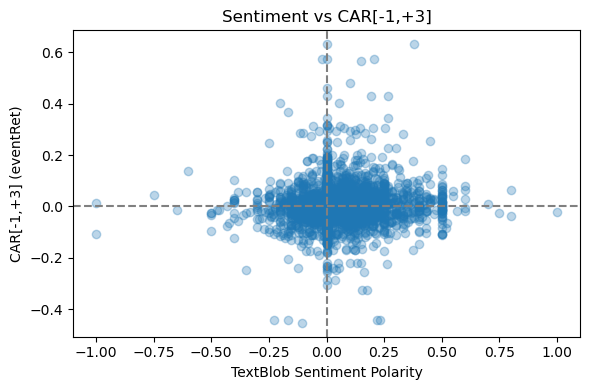

Overall correlation(sent_blob, eventRet): 0.05340438688227619


ticker
AAPL    0.094612
ADBE   -0.014748
AMZN    0.038098
FB      0.076971
GOOG    0.022428
JPM    -0.094102
MSFT   -0.067098
NFLX    0.059925
TSLA    0.101048
WMT     0.161770
Name: eventRet, dtype: float64

In [63]:
plt.figure(figsize=(6, 4))
plt.scatter(data_df["sent_blob"], data_df["eventRet"], alpha=0.3)
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("TextBlob Sentiment Polarity")
plt.ylabel("CAR[-1,+3] (eventRet)")
plt.title("Sentiment vs CAR[-1,+3]")
plt.tight_layout()
plt.show()

# Overall correlation
corr_overall = data_df["sent_blob"].corr(data_df["eventRet"])
print("Overall correlation(sent_blob, eventRet):", corr_overall)

# Correlation by ticker
corr_by_ticker = (
    data_df.groupby("ticker")[["sent_blob", "eventRet"]]
           .corr()
           .unstack()
)
corr_by_ticker = corr_by_ticker["sent_blob"]["eventRet"]
corr_by_ticker


3. Base model with textblob

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# label: CAR > 0 as 1, otherwise 0
data_df["label_up"] = (data_df["eventRet"] > 0).astype(int)

# sort by time and split into 80% train & 20% test
data_df = data_df.sort_values("date")
n = len(data_df)
split_idx = int(n * 0.8)

train = data_df.iloc[:split_idx]
test  = data_df.iloc[split_idx:]

X_train = train[["sent_blob"]]
y_train = train["label_up"]

X_test  = test[["sent_blob"]]
y_test  = test["label_up"]

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Test ACC:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_proba))


Test ACC: 0.5236363636363637
Test AUC: 0.5159859080313626


## Part 03: FinBERT

1. Load model

In [65]:
import torch, transformers
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)

torch: 2.9.0
transformers: 4.57.3


In [66]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# FinBERT
model_name = "ProsusAI/finbert"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

2. FinBert Scores

In [71]:
import numpy as np
import torch.nn.functional as F

id2label = model.config.id2label
print(id2label)     
inv_label = {v:k for k,v in id2label.items()}

@torch.no_grad()
def finbert_predict(texts, batch_size=32, max_length=128):
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        outputs = model(**enc)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


{0: 'positive', 1: 'negative', 2: 'neutral'}


In [72]:
data_df["headline"] = data_df["headline"].astype(str)
texts = data_df["headline"].tolist()

probs = finbert_predict(texts)

neg_idx = inv_label["negative"]
neu_idx = inv_label["neutral"]
pos_idx = inv_label["positive"]

data_df["finbert_neg"] = probs[:, neg_idx]
data_df["finbert_neu"] = probs[:, neu_idx]
data_df["finbert_pos"] = probs[:, pos_idx]

# define finbert_score = pos - neg
data_df["finbert_score"] = data_df["finbert_pos"] - data_df["finbert_neg"]

data_df[["headline", "finbert_pos", "finbert_neg", "finbert_neu", "finbert_score"]].head()

,headline,finbert_pos,finbert_neg,finbert_neu,finbert_score
0,Whole Foods (WFMI) -5.2% following a downgrade...,0.022275,0.940207,0.037519,-0.917932
1,Netflix (NFLX +1.1%) shares post early gains a...,0.951952,0.018521,0.029527,0.933431
2,The likely winners in Microsoft's (MSFT -1.4%)...,0.122482,0.010699,0.866818,0.111783
3,Microsoft (MSFT -1.2%) and Skype signed their ...,0.696708,0.008052,0.295240,0.688656
4,Amazon.com (AMZN -1.7%) shares slip as comment...,0.007746,0.969940,0.022314,-0.962194


3. FinBert & CAR

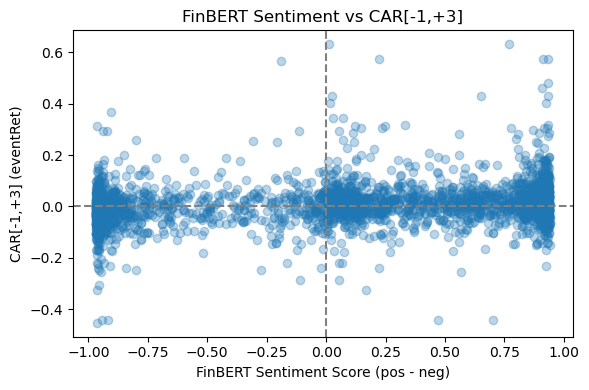

Overall correlation(finbert_score, eventRet): 0.22869139545157144


ticker
AAPL    0.292922
ADBE    0.396399
AMZN    0.151128
FB      0.304887
GOOG    0.183770
JPM     0.247951
MSFT    0.161183
NFLX    0.267429
TSLA    0.252949
WMT     0.350304
Name: eventRet, dtype: float64

In [73]:
plt.figure(figsize=(6, 4))
plt.scatter(data_df["finbert_score"], data_df["eventRet"], alpha=0.3)
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("FinBERT Sentiment Score (pos - neg)")
plt.ylabel("CAR[-1,+3] (eventRet)")
plt.title("FinBERT Sentiment vs CAR[-1,+3]")
plt.tight_layout()
plt.show()

# overall corr
corr_finbert = data_df["finbert_score"].corr(data_df["eventRet"])
print("Overall correlation(finbert_score, eventRet):", corr_finbert)

# corr. by ticker
corr_by_ticker_finbert = (
    data_df.groupby("ticker")[["finbert_score", "eventRet"]]
           .corr()
           .unstack()
)
corr_by_ticker_finbert = corr_by_ticker_finbert["finbert_score"]["eventRet"]
corr_by_ticker_finbert


4. Base model with FinBert

In [75]:
data_df["label_up"] = (data_df["eventRet"] > 0).astype(int)

data_df = data_df.sort_values("date")
n = len(data_df)
split_idx = int(n * 0.8)

train = data_df.iloc[:split_idx]
test  = data_df.iloc[split_idx:]

X_train = train[["finbert_score"]]
y_train = train["label_up"]
X_test  = test[["finbert_score"]]
y_test  = test["label_up"]

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("FinBERT Test ACC:", accuracy_score(y_test, y_pred))
print("FinBERT Test AUC:", roc_auc_score(y_test, y_proba))


FinBERT Test ACC: 0.5763636363636364
FinBERT Test AUC: 0.5991867980504344


## Part 4: Adding structural features

In [78]:
DATA_DIR = Path("../data/")

prices = pd.read_csv(DATA_DIR / "prices_data.csv")
prices["Date"] = pd.to_datetime(prices["Date"], utc=True)
prices["date"] = prices["Date"].dt.date
prices = prices.sort_values(["ticker", "Date"])

prices["ret1"]  = prices.groupby("ticker")["Close"].pct_change()
prices["ret5"]  = prices.groupby("ticker")["Close"].pct_change(5)
prices["vol20"] = (
    prices.groupby("ticker")["ret1"]
          .rolling(20)
          .std()
          .reset_index(level=0, drop=True)
)

struct = prices[["ticker", "date", "ret1", "ret5", "vol20"]]

data_df = data_df.copy()
data_df["date"] = pd.to_datetime(data_df["date"]).dt.date

data_merged = data_df.merge(
    struct,
    on=["ticker", "date"],
    how="left"
)

print("data_merged columns:", data_merged.columns.tolist())
data_merged.head()

data_merged columns: ['ticker', 'headline', 'date', 'Close', 'eventRet', 'sent_blob', 'label_up', 'finbert_neg', 'finbert_neu', 'finbert_pos', 'finbert_score', 'ret1', 'ret5', 'vol20']


,ticker,headline,date,Close,eventRet,sent_blob,label_up,finbert_neg,finbert_neu,finbert_pos,finbert_score,ret1,ret5,vol20
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,10.059500,0.011007,0.262500,1,0.940207,0.037519,0.022275,-0.917932,0.027476,0.085050,0.021736
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,33.884285,-0.016891,-0.043750,0,0.018521,0.029527,0.951952,0.933431,0.019427,-0.057536,0.028217
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,20.120024,-0.032847,0.166667,0,0.010699,0.866818,0.122482,0.111783,-0.006194,-0.005424,0.012662
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,20.120024,-0.032847,-0.030556,0,0.008052,0.295240,0.696708,0.688656,-0.006194,-0.005424,0.012662
4,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,10.303500,-0.044274,0.000000,0,0.969940,0.022314,0.007746,-0.962194,0.008269,0.045457,0.021330


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


events = data_merged.copy()
print([c for c in events.columns if c in 
       ["eventRet","finbert_score","ret1","ret5","vol20"]])

features_all = ["ret1", "ret5", "vol20", "finbert_score"]

events = events.dropna(subset=features_all + ["eventRet"]).copy()
events = events.sort_values("date")

# label：CAR>0 as 1
events["label_up"] = (events["eventRet"] > 0).astype(int)

X_all = events[features_all]
y_all = events["label_up"]

# 80% train, 20% test
X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=False
)

print("train size:", X_tr_all.shape, "test size:", X_te_all.shape)

# structural
features_struct = ["ret1", "ret5", "vol20"]

X_tr_struct = X_tr_all[features_struct]
X_te_struct = X_te_all[features_struct]

clf_struct = LogisticRegression(max_iter=1000)
clf_struct.fit(X_tr_struct, y_tr_all)

y_pred_struct  = clf_struct.predict(X_te_struct)
y_proba_struct = clf_struct.predict_proba(X_te_struct)[:, 1]

print("\n=== Struct-only model ===")
print("Struct-only ACC:", accuracy_score(y_te_all, y_pred_struct))
print("Struct-only AUC:", roc_auc_score(y_te_all, y_proba_struct))

# structural + FinBERT
features_struct_finbert = ["ret1", "ret5", "vol20", "finbert_score"]

X_tr_sf = X_tr_all[features_struct_finbert]
X_te_sf = X_te_all[features_struct_finbert]

clf_sf = LogisticRegression(max_iter=1000)
clf_sf.fit(X_tr_sf, y_tr_all)

y_pred_sf  = clf_sf.predict(X_te_sf)
y_proba_sf = clf_sf.predict_proba(X_te_sf)[:, 1]

print("\n=== Struct + FinBERT model ===")
print("Struct+FinBERT ACC:", accuracy_score(y_te_all, y_pred_sf))
print("Struct+FinBERT AUC:", roc_auc_score(y_te_all, y_proba_sf))

print("\nStruct-only coefficients:")
for f, c in zip(features_struct, clf_struct.coef_[0]):
    print(f"{f:12s}: {c:.4f}")

print("\nStruct+FinBERT coefficients:")
for f, c in zip(features_struct_finbert, clf_sf.coef_[0]):
    print(f"{f:12s}: {c:.4f}")


['eventRet', 'finbert_score', 'ret1', 'ret5', 'vol20']
train size: (2187, 4) test size: (547, 4)

=== Struct-only model ===
Struct-only ACC: 0.6837294332723949
Struct-only AUC: 0.7504085952361814

=== Struct + FinBERT model ===
Struct+FinBERT ACC: 0.6563071297989032
Struct+FinBERT AUC: 0.7232269646062749

Struct-only coefficients:
ret1        : 8.6593
ret5        : 7.0486
vol20       : -0.3466

Struct+FinBERT coefficients:
ret1        : 7.8738
ret5        : 6.4535
vol20       : -0.2502
finbert_score: 0.4345
